# 01 数据质量与生命周期：客户带着什么历史信息走到今天？

## 业务问题

1. 这份数据**质量如何**：有没有缺失值、unknown 占比多高、目标变量是否类别不平衡？
2. 每行是一次外呼活动记录，**客户带着什么历史信息走到今天**：首次触达 vs 回归客各占多少、转化率差多少？
3. 用历史痕迹字段（`previous`/`pdays`/`poutcome`）能把客户分成哪些**生命周期层**，各层转化率如何？
4. **再触达窗口**（`pdays`）有什么描述性发现——上次联系距今多久，转化率有没有衰减？

本 notebook 的产出（分层口径、旅程定义）将被 notebooks/02、03、04、05 直接复用。

## 口径与方法假设定义

### 数据质量校验范围

- 缺失值：检查 `NaN`（本数据集缺失信息以字符串 `unknown` 编码，两者都要查）；
- unknown 占比：逐字段统计 `unknown` 条数与占比；
- 类别不平衡：目标变量 `y` 正类占比（约 11%，评估指标不能用 Accuracy，详见 notebook 03）；
- **pdays 哨兵值一致性**：`pdays=999` 的官方含义是"从未联系过"，但需核对它与 `previous>0`（曾联系）是否矛盾——这决定旅程定义用哪个字段。

### 用户旅程定义（first_time / returning）

| 旅程段 | 判定口径 | 含义 |
|---|---|---|
| first_time（首次触达） | `previous == 0` | 本次活动之前从未被联系过 |
| returning（回归客） | `previous > 0` | 曾被联系过，按 `pdays` 再拆"窗口内/窗口外" |

> 为什么不用 `pdays != 999` 判定回归客：见下方数据质量检查——`pdays=999` 并不严格等价于"从未接触"，存在"曾联系但时间未记录"的记录。因此**一律用 `previous>0` 判定回归客**，这是全系列 notebook 的统一口径。

### 生命周期分层（5类）

用当前活动可观测的历史痕迹字段重建的**近似状态**（非纵向追踪，见文末局限性声明），5 类互斥且覆盖全体：

| 分层 | 判定口径 | 业务含义 |
|---|---|---|
| 1. 新客（从未接触） | `previous == 0` | 冷线索，无任何历史 |
| 2. 老客·曾成功 | `poutcome == success` | 上次活动转化成功 |
| 3. 老客·近期失败（≤27天） | `poutcome == failure` 且 `pdays != 999` | 上次失败，但仍处于再触达窗口内 |
| 4. 老客·历史失败·轻触达 | `poutcome == failure` 且 `pdays == 999` 且 `previous == 1` | 只被联系过 1 次且失败 |
| 5. 老客·历史失败·重触达 | `poutcome == failure` 且 `pdays == 999` 且 `previous >= 2` | 被联系 2 次及以上仍失败 |

> **口径修正记录（为什么不用"按天数分"）**：规划阶段原计划为"新客 / 曾成功 / 近期失败(≤30天) / 历史失败重新激活(>30天) / 边缘兜底类 Unknown_History"。执行时数据现实推翻了两点：(1) 非 999 的 `pdays` 全部 ≤27 天，`pdays∈(27,999)` 的记录为 **0**——">30天重新激活"类在这份数据里无样本，天数二分不可行；(2) `poutcome=nonexistent 且 previous>0` 的记录为 **0**——数据中 `previous` 与 `poutcome` 完全互斥，不存在需要兜底的"Unknown_History"组合。故"近期"以数据实际窗口 **27 天**为界；"历史失败"类改用可靠字段 `previous` 的次数细分为轻/重触达；兜底类因数据中无此组合而取消。完整决策记录见 `docs/00_methodology_notes.md` §2.4。

### 再触达窗口（pdays_bucket）

非 999 的 `pdays` 全部 ≤27 天，分桶：`=0天`、`1-3天`、`4-7天`、`8-14天`、`15-27天`、`999（从未/不可考）`。

### duration 的处置（沿用 00 文档声明一）

`duration`（本次通话时长）是**数据泄漏字段**：只有客户表现出兴趣、销售才会持续通话。本 notebook 不将其用于任何分层/预测口径；本系列全程也不把 duration 用作决策/预测特征，如有 EDA 使用会显式标注"解释用途，非预测/决策用途"。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# 定位项目根目录（兼容从项目根或 notebooks/ 目录启动内核），并加入模块搜索路径
_CWD = Path.cwd()
_PROBE = Path("src") / "telemarketing_utils.py"
if not (_CWD / _PROBE).exists() and (_CWD.parent / _PROBE).exists():
    sys.path.insert(0, str(_CWD.parent))
else:
    sys.path.insert(0, str(_CWD))

from src.telemarketing_utils import find_project_root, setup_plot_style  # noqa: E402

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-additional-full.csv"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)

setup_plot_style()
import matplotlib.pyplot as plt  # noqa: E402  # 必须在 setup_plot_style() 之后导入

print("项目根目录:", PROJECT_ROOT)

项目根目录: /home/arleszhang/data-strategy-portfolio/outbound-sales-strategy-analysis


In [2]:
df = pd.read_csv(DATA_PATH, sep=";")
print("形状:", df.shape)
print("字段数:", df.shape[1])
print()
print("字段与类型:")
df.dtypes

形状: (41188, 21)
字段数: 21

字段与类型:


age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# 数据质量检查 1/3：NaN 缺失值
n_missing = int(df.isna().sum().sum())
print("全表 NaN 缺失值总数:", n_missing)

# 数据质量检查 2/3：缺失信息以 'unknown' 字符串编码，逐字段统计
unknown_cnt = (df == "unknown").sum()
unknown_pct = (unknown_cnt / len(df) * 100).round(2)
unknown_summary = pd.DataFrame({"unknown条数": unknown_cnt, "占比%": unknown_pct})
unknown_summary = unknown_summary[unknown_summary["unknown条数"] > 0].sort_values("占比%", ascending=False)
unknown_summary

全表 NaN 缺失值总数: 0


,unknown条数,占比%
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


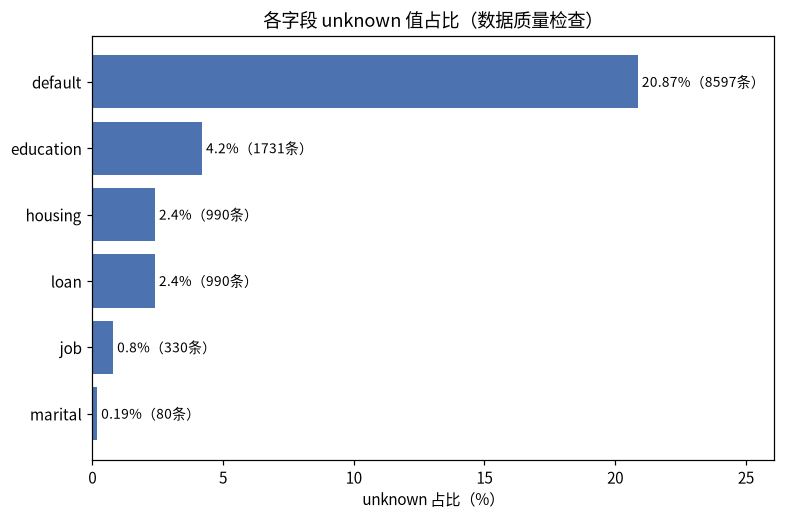

In [5]:
# unknown 占比可视化（仅展示存在 unknown 的字段）
fig, ax = plt.subplots(figsize=(8, 5))
order = unknown_summary.index[::-1]  # 横向条形图自下而上由低到高
vals = unknown_summary.loc[order]
bars = ax.barh(order, vals["占比%"], color="#4C72B0")
for bar, (pct, cnt) in zip(bars, zip(vals["占比%"], vals["unknown条数"])):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{pct}%（{int(cnt)}条）",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("unknown 占比（%）")
ax.set_title("各字段 unknown 值占比（数据质量检查）")
ax.set_xlim(0, max(vals["占比%"]) * 1.25)
plt.savefig(REPORT_DIR / "01_unknown_rate.png", bbox_inches="tight")
plt.show()

**数据质量发现**：全表无 `NaN`，缺失信息全部以 `unknown` 字符串编码。unknown 占比最高的字段是 `default`（是否有信用违约，20.9%），其次 `education`（4.2%）、`housing`/`loan`（各 2.4%）、`job`（0.8%）、`marital`（0.2%）。这些字段若进入后续模型特征集（notebooks/02、03、04），需考虑 unknown 的处理方式。

In [6]:
# 数据质量检查 3/3：目标变量类别不平衡
y_dist = df["y"].value_counts(normalize=True)
print("目标变量 y 分布（n={}）：".format(len(df)))
print(y_dist.round(4))
print(f"正类（办理定存）占比: {y_dist['yes']:.2%}")

目标变量 y 分布（n=41188）：
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64
正类（办理定存）占比: 11.27%


**类别不平衡**：正类（`yes`）仅 **11.27%**，负类 88.73%。后续任何模型评估不得只看 Accuracy（全预测"否"即可拿到 88.7% 的 Accuracy）；notebook 03 将使用 AUC、Precision-Recall 与 Gains Chart 等对不平衡不敏感的评估方式。

In [7]:
# 数据质量检查（额外）：pdays=999 哨兵值与 previous 的一致性
p999_prev_gt0 = int(((df["pdays"] == 999) & (df["previous"] > 0)).sum())
p999_prev_eq0 = int(((df["pdays"] == 999) & (df["previous"] == 0)).sum())
p999_failure = int(((df["pdays"] == 999) & (df["poutcome"] == "failure")).sum())
print(f"pdays==999 且 previous>0（曾联系但时间未记录）: {p999_prev_gt0} 条")
print(f"pdays==999 且 previous==0（确实从未联系）: {p999_prev_eq0} 条")
print(f"其中 poutcome==failure 的条数: {p999_failure} 条")
print()
print("pdays != 999 的记录数:", int((df["pdays"] != 999).sum()))
print(
    "pdays != 999 的取值范围:",
    df.loc[df["pdays"] != 999, "pdays"].min(),
    "~",
    df.loc[df["pdays"] != 999, "pdays"].max(),
    "天",
)

pdays==999 且 previous>0（曾联系但时间未记录）: 4110 条
pdays==999 且 previous==0（确实从未联系）: 35563 条
其中 poutcome==failure 的条数: 4110 条

pdays != 999 的记录数: 1515
pdays != 999 的取值范围: 0 ~ 27 天


**重要发现（决定旅程定义口径）**：`pdays=999` 的官方含义是"从未联系过"，但实际有 **4,110 条**记录是"`previous>0`（曾联系）但 `pdays=999`（时间未记录）"，且全部是上次失败（`poutcome=failure`）的记录。因此：

- `pdays=999` **并不严格等价于"从未接触"**，不能单独用它判定 first_time；
- 旅程定义统一用 `previous>0` 判定"回归客"（与 00 文档口径一致）；
- 非 999 的 `pdays` 全部落在 **0–27 天**——"再触达窗口"实际上就是近 4 周。

In [8]:
# 用户旅程：first_time / returning（口径见上文）
df["journey"] = np.where(df["previous"] == 0, "first_time", "returning")
df["journey_detail"] = np.select(
    [
        df["previous"] == 0,
        (df["previous"] > 0) & (df["pdays"] != 999),
        (df["previous"] > 0) & (df["pdays"] == 999),
    ],
    ["首次触达", "回归·窗口内（≤27天）", "回归·窗口外/时间不可考"],
    default="未分类",  # numpy 2.5 严格 dtype 提升：default 必须与 choicelist 同为字符串
)

journey_tab = (
    df.groupby("journey_detail")
    .agg(
        记录数=("y", "size"),
        占比=("y", lambda s: len(s) / len(df)),
        转化率=("y", lambda s: (s == "yes").mean()),
    )
    .reindex(["首次触达", "回归·窗口内（≤27天）", "回归·窗口外/时间不可考"])
)
journey_tab = journey_tab.round(4)
journey_tab

,记录数,占比,转化率
journey_detail,,,
首次触达,35563,0.8634,0.0883
回归·窗口内（≤27天）,1515,0.0368,0.6383
回归·窗口外/时间不可考,4110,0.0998,0.1294


**旅程分布**：86.3% 的记录是首次触达（从未被联系过），回归客只占 13.7%；其中处于 27 天再触达窗口内的仅 3.7%。但转化率呈明显梯度：首次触达 8.8% → 窗口外回归客 12.9% → 窗口内回归客 63.8%。**"曾经联系过"本身就是最强的转化信号之一**——这正是 04 里需要警惕的选择偏差来源：渠道分配与历史痕迹高度相关。

In [9]:
# 生命周期分层（5类）：用历史痕迹字段重建的近似状态，口径见上文
conds = [
    df["previous"] == 0,                                                            # 1 新客
    df["poutcome"] == "success",                                                    # 2 曾成功
    (df["poutcome"] == "failure") & (df["pdays"] != 999),                           # 3 近期失败（≤27天）
    (df["poutcome"] == "failure") & (df["pdays"] == 999) & (df["previous"] == 1),   # 4 历史失败·轻触达
    (df["poutcome"] == "failure") & (df["pdays"] == 999) & (df["previous"] >= 2),   # 5 历史失败·重触达
]
labels = [
    "新客（从未接触）",
    "老客·曾成功",
    "老客·近期失败（≤27天）",
    "老客·历史失败·轻触达",
    "老客·历史失败·重触达",
]
df["lifecycle"] = np.select(conds, labels, default="未分类")
assert (df["lifecycle"] != "未分类").all(), "分层必须互斥且覆盖全体样本"

# 边缘情况核实：原计划拟设兜底类 Unknown_History（poutcome=nonexistent 且 previous>0）。
# 数据检查结果：此类组合为 0 条——previous 与 poutcome 完全互斥，无需兜底类（决策记录见 docs/00_methodology_notes.md §2.4）
edge_cases = int(((df["poutcome"] == "nonexistent") & (df["previous"] > 0)).sum())
print("边缘情况核实：poutcome=nonexistent 且 previous>0 的记录数 =", edge_cases)

lifecycle_tab = (
    df.groupby("lifecycle")
    .agg(
        记录数=("y", "size"),
        占比=("y", lambda s: len(s) / len(df)),
        转化率=("y", lambda s: (s == "yes").mean()),
    )
    .sort_values("转化率", ascending=False)
)
lifecycle_tab = lifecycle_tab.round(4)
lifecycle_tab

边缘情况核实：poutcome=nonexistent 且 previous>0 的记录数 = 0


,记录数,占比,转化率
lifecycle,,,
老客·曾成功,1373,0.0333,0.6511
老客·近期失败（≤27天）,142,0.0034,0.5141
老客·历史失败·重触达,414,0.0101,0.1957
老客·历史失败·轻触达,3696,0.0897,0.1220
新客（从未接触）,35563,0.8634,0.0883


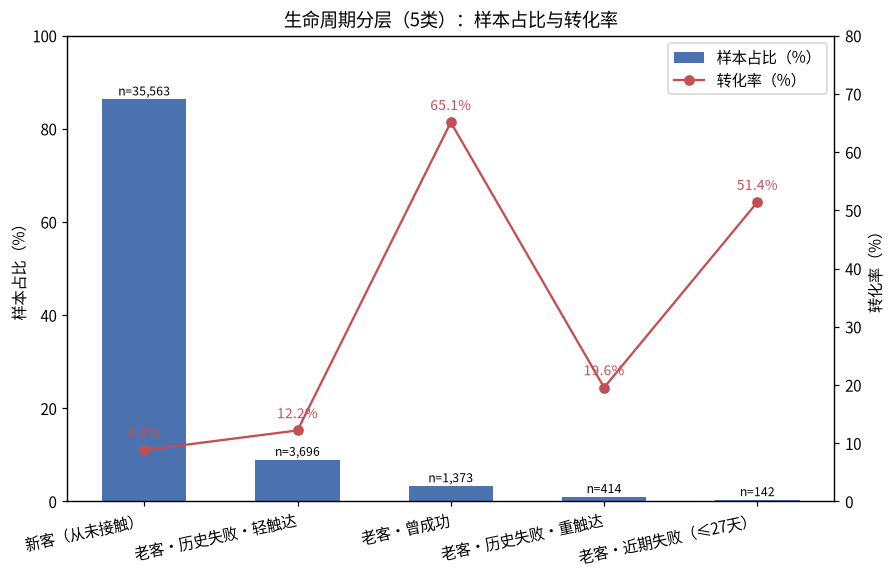

In [10]:
# 生命周期分层可视化：样本占比（柱）+ 转化率（线，右轴）
fig, ax1 = plt.subplots(figsize=(9, 5.5))
tab = lifecycle_tab.sort_values("记录数", ascending=False)
x = np.arange(len(tab))
ax1.bar(x, tab["占比"] * 100, width=0.55, color="#4C72B0", label="样本占比（%）")
for xi, (n, p) in enumerate(zip(tab["记录数"], tab["占比"])):
    ax1.text(xi, p * 100 + 0.8, f"n={n:,}", ha="center", fontsize=8)
ax1.set_ylabel("样本占比（%）")
ax1.set_ylim(0, 100)
ax1.set_xticks(x)
ax1.set_xticklabels(tab.index, rotation=12, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, tab["转化率"] * 100, "o-", color="#C44E52", label="转化率（%）")
ax2.set_ylabel("转化率（%）")
ax2.set_ylim(0, 80)
for xi, c in enumerate(tab["转化率"]):
    ax2.annotate(
        f"{c:.1%}",
        (xi, c * 100),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        color="#C44E52",
    )
ax1.set_title("生命周期分层（5类）：样本占比与转化率")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
plt.savefig(REPORT_DIR / "01_lifecycle_conversion.png", bbox_inches="tight")
plt.show()

**生命周期分层结果**（5 类转化率从高到低）：

1. **老客·曾成功 65.1%**——历史成功是最强信号（占比 3.3%）；
2. **老客·近期失败（≤27天）51.4%**——刚被拒绝的客户仍是热线索（占比 0.3%）；
3. 老客·历史失败·重触达 19.6%、轻触达 12.2%——同样是"上次失败"，被联系次数越多，转化率反而越高（销售的主观筛选信号，注意因果方向）；
4. **新客 8.8%**——转化率最低，但占比 86.3%，是外呼资源的主战场。

转化率最高为"老客·曾成功"（65.1%），最低为"新客"（8.8%），相差约 56 个百分点。

In [11]:
# 再触达窗口描述性分析：pdays 分桶
bins = [-1, 0, 3, 7, 14, 27, 999]
bucket_labels = ["=0天", "1-3天", "4-7天", "8-14天", "15-27天", "999（从未/不可考）"]
df["pdays_bucket"] = pd.cut(df["pdays"], bins=bins, labels=bucket_labels)

bucket_tab = (
    df.groupby("pdays_bucket", observed=True)
    .agg(
        记录数=("y", "size"),
        占比=("y", lambda s: len(s) / len(df)),
        转化率=("y", lambda s: (s == "yes").mean()),
    )
    .round(4)
)
bucket_tab

,记录数,占比,转化率
pdays_bucket,,,
=0天,15,0.0004,0.6667
1-3天,526,0.0128,0.6521
4-7天,636,0.0154,0.6619
8-14天,276,0.0067,0.5688
15-27天,62,0.0015,0.5806
999（从未/不可考）,39673,0.9632,0.0926


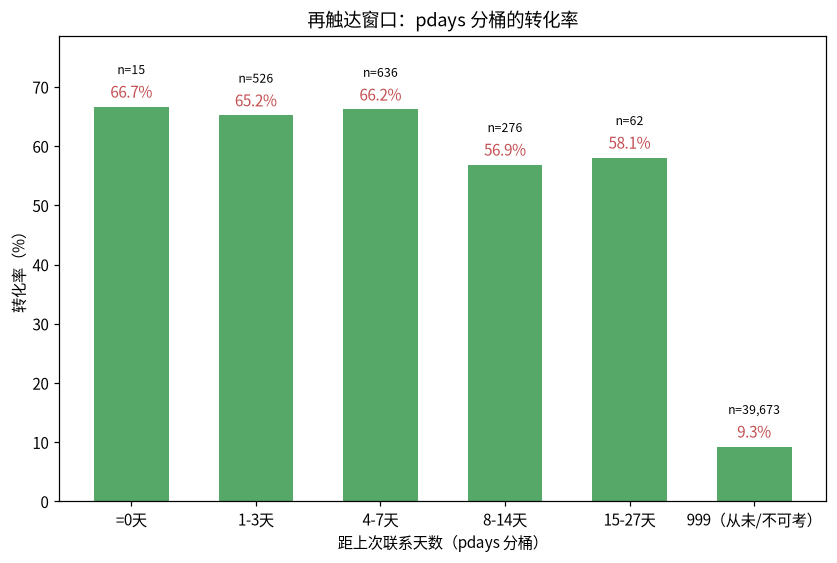

In [12]:
# 再触达窗口可视化：各 pdays 分桶转化率
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(bucket_tab))
bars = ax.bar(x, bucket_tab["转化率"] * 100, color="#55A868", width=0.6)
for xi, (n, c) in enumerate(zip(bucket_tab["记录数"], bucket_tab["转化率"])):
    ax.text(xi, c * 100 + 1.5, f"{c:.1%}", ha="center", fontsize=10, color="#C44E52")
    ax.text(xi, c * 100 + 5.5, f"n={n:,}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(bucket_tab.index)
ax.set_xlabel("距上次联系天数（pdays 分桶）")
ax.set_ylabel("转化率（%）")
ax.set_title("再触达窗口：pdays 分桶的转化率")
ax.set_ylim(0, max(bucket_tab["转化率"] * 100) + 12)
plt.savefig(REPORT_DIR / "01_pdays_bucket.png", bbox_inches="tight")
plt.show()

**再触达窗口的描述性发现**：

- 96.3% 的记录 `pdays=999`（从未联系或时间不可考），转化率 9.3%；
- 所有非 999 记录都落在 **0–27 天**内：即销售对老客户的再触达集中在近 4 周；
- 转化率呈**时间衰减**：0–7 天内约 66%，8–14 天 56.9%，15–27 天 58.1%——**首周是再触达的黄金窗口**，一周后热度明显下降一个台阶。

> 警示（口径声明）：窗口内样本是"销售选择性再触达"的结果，样本本身有选择偏差——**此处仅作描述性呈现，不做任何因果解读**；"渠道/客群差异导致的假象"问题在 notebook 04 用 PSM 正式处理。

## 局限性声明：无客户唯一 ID

本数据集**没有客户唯一标识**，每一行是一次外呼活动记录，而不是一个客户。这意味着：

1. 本 notebook 中的"用户旅程"（first_time / returning）和"生命周期分层（5类）"，都是用**当前这次活动里可观测的历史痕迹字段**（`previous`、`pdays`、`poutcome`）重建的**近似状态**，不是对同一客户跨活动的纵向追踪；
2. 同一客户在数据集里可能出现多次（每次外呼一条记录），但我们无法把属于同一个人的记录关联起来，因此"回归客"的确切回访周期、跨活动留存等真正的纵向指标**无法计算**；
3. 因此，分层结论的业务含义是"**当前活动中带有这类历史痕迹的客户**"，而不是"处于该生命周期阶段的客户个体"。后续 notebook（02/03/04/05）引用这些分层时，均沿用这一口径。

## 业务解读与决策建议

**这份数据"客户带着什么历史信息走到今天"的答案是：86.3% 的客户是首次被触达的新客，只有 13.7% 带历史痕迹；但历史痕迹的转化信号极强，转化率按"新客 → 历史失败 → 近期失败/曾成功"逐级跃升，最高与最低相差约 56 个百分点。**

1. **数据质量结论**：无 NaN；unknown 集中在 `default`（20.9%）与 `education`（4.2%），后续建模需明确 unknown 的处理策略；`pdays=999` 哨兵值不完全等价"从未接触"（4,110 条曾联系记录同样为 999），旅程定义必须以 `previous` 为准。
2. **资源优先级建议**：外呼资源应优先投向"老客·曾成功"（65.1%）与"老客·近期失败（≤27天）"（51.4%）两类——合计仅占样本 3.7%，但转化潜力是均值的 5 倍以上。
3. **节奏建议**：对回归客的再触达应在**上次联系后首周内**完成（首周转化约 66%，一周后降至约 57%）；超过 27 天未再触达的记录在本数据中不存在——27 天可能是该电销团队的再触达周期上限，可作为节奏设计的参照边界。
4. **新客是主战场也是难点**：新客占 86.3% 但转化率仅 8.8%。如何在新客中识别高潜力个体，交给 notebook 03 的分层评分模型（剔除 duration）；哪些特征驱动转化、分旅程阶段是否有差异，交给 notebook 02。
5. **口径警示（承接后续 notebook）**：生命周期分层是"历史痕迹近似状态"（无客户唯一 ID，非纵向追踪）；窗口内客群的高转化可能部分是销售选择性再触达的结果——这是典型的**选择偏差**，正是 notebook 04 用 PSM 处理的"朴素比较 vs 调整后效应"问题的预演。